# Notebook 04: Modelo de Optimizacion de Rutas
## TransCarga S.A.S. - Vehicle Routing Problem (VRP)

**Objetivo**: Optimizar rutas de entrega usando Google OR-Tools

**Modelo**: CVRP (Capacitated Vehicle Routing Problem)

**Restricciones:**
- Capacidad maxima del vehiculo
- Minimizar distancia total
- Visita unica a cada cliente

In [1]:
# CELDA 1: Importar librerias
import os
import sys
import pandas as pd
import numpy as np
import json
from datetime import datetime, timedelta
import logging
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Google OR-Tools
from ortools.constraint_solver import routing_enums_pb2
from ortools.constraint_solver import pywrapcp

# Configuracion
BASE_DIR = r'C:\Users\danie\OneDrive\Documentos\TransCarga_ETL'
OUTPUT_DIR = os.path.join(BASE_DIR, 'datos', 'output')
RESULTS_DIR = os.path.join(BASE_DIR, 'datos', 'results')
LOGS_DIR = os.path.join(BASE_DIR, 'logs')

for d in [RESULTS_DIR, LOGS_DIR]:
    os.makedirs(d, exist_ok=True)

# Logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(os.path.join(LOGS_DIR, 'optimizacion.log')),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

print("="*70)
print("MODELO DE OPTIMIZACION DE RUTAS - TransCarga S.A.S.")
print("="*70)
logger.info("Modelo de optimizacion iniciado")

2026-05-11 13:41:48,524 - INFO - Modelo de optimizacion iniciado


MODELO DE OPTIMIZACION DE RUTAS - TransCarga S.A.S.


In [2]:
# CELDA 2: Cargar datos del ETL
print("\n" + "="*70)
print("CARGANDO DATOS DEL ETL")
print("="*70)

# Cargar clientes
clientes_path = os.path.join(OUTPUT_DIR, 'optimizacion_clientes.csv')
clientes = pd.read_csv(clientes_path)
print(f"Clientes: {len(clientes)}")

# Cargar vehiculos (ordenar por capacidad descendente)
vehiculos_path = os.path.join(OUTPUT_DIR, 'optimizacion_vehiculos.csv')
vehiculos = pd.read_csv(vehiculos_path)
vehiculos = vehiculos.sort_values('capacidad_kg', ascending=False)
print(f"Vehiculos disponibles: {len(vehiculos)}")

# Cargar bodegas
bodegas_path = os.path.join(OUTPUT_DIR, 'optimizacion_bodegas.csv')
bodegas = pd.read_csv(bodegas_path)
print(f"Bodegas: {len(bodegas)}")

# Cargar matriz de distancias
distancias_path = os.path.join(OUTPUT_DIR, 'optimizacion_matriz_distancias.csv')
matriz_distancias = pd.read_csv(distancias_path, index_col=0)
print(f"Matriz distancias: {matriz_distancias.shape}")

logger.info("Datos cargados exitosamente")

2026-05-11 13:41:48,577 - INFO - Datos cargados exitosamente



CARGANDO DATOS DEL ETL
Clientes: 200
Vehiculos disponibles: 64
Bodegas: 2
Matriz distancias: (52, 52)


In [3]:
# CELDA 3: Preparar datos para OR-Tools
print("\n" + "="*70)
print("PREPARANDO DATOS PARA OPTIMIZACION")
print("="*70)

# Funcion Haversine
from math import radians, sin, cos, sqrt, atan2

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

# Seleccionar clientes (filtrar por demanda pequena)
clientes_small = clientes[clientes['capacidad_kg'] <= 1000].head(20)
print(f"Clientes seleccionados: {len(clientes_small)}")

# Seleccionar vehiculos con mayor capacidad
n_vehiculos = 5
vehiculos_top = vehiculos.head(n_vehiculos)
vehicle_capacities = vehiculos_top['capacidad_kg'].tolist()
print(f"Vehiculos: {n_vehiculos}")
print(f"Capacidades: {vehicle_capacities}")
print(f"Capacidad total: {sum(vehicle_capacities)} kg")

# Crear locations
locations = []

# Bodega (indice 0)
bodega = bodegas.iloc[0]
locations.append({
    'id': bodega['id_bodega'],
    'nombre': bodega['nombre'],
    'lat': bodega['latitud'],
    'lon': bodega['longitud'],
    'demanda': 0
})

# Clientes
for idx, row in clientes_small.iterrows():
    locations.append({
        'id': row['id_cliente'],
        'nombre': row.get('nombre', f"Cliente {idx}"),
        'lat': row['latitud'],
        'lon': row['longitud'],
        'demanda': row['capacidad_kg']
    })

n_locations = len(locations)
print(f"\nLocations: {n_locations} (1 bodega + {n_locations-1} clientes)")

# Calcular matriz de distancias
distance_matrix = []
for i in range(n_locations):
    row = []
    for j in range(n_locations):
        if i == j:
            row.append(0)
        else:
            d = haversine(locations[i]['lat'], locations[i]['lon'],
                          locations[j]['lat'], locations[j]['lon'])
            row.append(int(d * 1000))  # metros
    distance_matrix.append(row)

# Demands
demands = [loc['demanda'] for loc in locations]
print(f"Demanda total: {sum(demands)} kg")
print(f"Factor de utilizacion: {sum(demands)/sum(vehicle_capacities)*100:.1f}%")

logger.info(f"Datos preparados: {n_locations} locations, {n_vehiculos} vehiculos")

2026-05-11 13:41:48,602 - INFO - Datos preparados: 21 locations, 5 vehiculos



PREPARANDO DATOS PARA OPTIMIZACION
Clientes seleccionados: 20
Vehiculos: 5
Capacidades: [2000, 2000, 2000, 2000, 2000]
Capacidad total: 10000 kg

Locations: 21 (1 bodega + 20 clientes)
Demanda total: 10000 kg
Factor de utilizacion: 100.0%


In [4]:
# CELDA 4: Crear y resolver modelo
print("\n" + "="*70)
print("CREANDO Y RESOLVIENDO MODELO")
print("="*70)

# Crear modelo
manager = pywrapcp.RoutingIndexManager(n_locations, n_vehiculos, 0)
routing = pywrapcp.RoutingModel(manager)

# Distance callback
def distance_callback(from_index, to_index):
    from_node = manager.IndexToNode(from_index)
    to_node = manager.IndexToNode(to_index)
    return distance_matrix[from_node][to_node]

transit_callback_index = routing.RegisterTransitCallback(distance_callback)
routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

# Capacity constraint
def demand_callback(from_index):
    from_node = manager.IndexToNode(from_index)
    return demands[from_node]

demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
routing.AddDimensionWithVehicleCapacity(
    demand_callback_index,
    0,
    vehicle_capacities,
    True,
    'Capacity'
)

# Search parameters
search_parameters = pywrapcp.DefaultRoutingSearchParameters()
search_parameters.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
search_parameters.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
search_parameters.time_limit.seconds = 60

print(f"Estrategia: PATH_CHEAPEST_ARC + GUIDED_LOCAL_SEARCH")
print(f"Tiempo limite: 60 segundos")
print(f"\nResolviendo...")

# Resolver
start_time = datetime.now()
solution = routing.SolveWithParameters(search_parameters)
end_time = datetime.now()
elapsed = (end_time - start_time).total_seconds()

if solution:
    print(f"\n[OK] Solucion encontrada en {elapsed:.2f} segundos")
    logger.info(f"Solucion encontrada en {elapsed:.2f}s")
else:
    print(f"\n[ERROR] No se encontro solucion")
    logger.error("No se encontro solucion")


CREANDO Y RESOLVIENDO MODELO
Estrategia: PATH_CHEAPEST_ARC + GUIDED_LOCAL_SEARCH
Tiempo limite: 60 segundos

Resolviendo...


2026-05-11 13:42:48,626 - INFO - Solucion encontrada en 60.00s



[OK] Solucion encontrada en 60.00 segundos


In [5]:
# CELDA 5: Extraer rutas
print("\n" + "="*70)
print("RUTAS OPTIMIZADAS")
print("="*70)

if solution:
    rutas = []
    total_distance = 0
    
    for vehicle_id in range(n_vehiculos):
        index = routing.Start(vehicle_id)
        route = []
        route_distance = 0
        route_demand = 0
        
        print(f"\n--- Vehiculo {vehicle_id + 1} (Capacidad: {vehicle_capacities[vehicle_id]} kg) ---")
        
        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            loc = locations[node]
            
            if node > 0:  # No es depot
                print(f"  {len(route)}. {loc['id']}: {loc['nombre'][:25]} | Demanda: {loc['demanda']} kg")
                route_demand += loc['demanda']
            
            route.append({
                'vehiculo_id': vehicle_id + 1,
                'orden': len(route),
                'location_idx': node,
                'id': loc['id'],
                'nombre': loc['nombre'],
                'latitud': loc['lat'],
                'longitud': loc['lon'],
                'demanda': loc['demanda']
            })
            
            previous_index = index
            index = solution.Value(routing.NextVar(index))
            route_distance += routing.GetArcCostForVehicle(previous_index, index, vehicle_id)
        
        # Nodo final
        node = manager.IndexToNode(index)
        route.append({
            'vehiculo_id': vehicle_id + 1,
            'orden': len(route),
            'location_idx': node,
            'id': 'DEPOT',
            'nombre': 'Fin de Ruta',
            'latitud': locations[0]['lat'],
            'longitud': locations[0]['lon'],
            'demanda': 0
        })
        
        total_distance += route_distance
        
        print(f"  -> FIN DE RUTA")
        print(f"\n  Distancia: {route_distance/1000:.1f} km")
        print(f"  Carga: {route_demand} kg ({route_demand/vehicle_capacities[vehicle_id]*100:.0f}% capacidad)")
        print(f"  Paradas: {len(route) - 2} clientes")
        
        rutas.extend(route)
    
    print(f"\n" + "="*70)
    print(f"DISTANCIA TOTAL: {total_distance/1000:.1f} km")
    print("="*70)
    
    df_rutas = pd.DataFrame(rutas)
    logger.info(f"Rutas extraidas: {len(df_rutas)} paradas")
else:
    df_rutas = None
    print("No hay solucion para mostrar")

2026-05-11 13:42:48,651 - INFO - Rutas extraidas: 30 paradas



RUTAS OPTIMIZADAS

--- Vehiculo 1 (Capacidad: 2000 kg) ---
  1. C00015: Cliente TRUJILLO 15 | Demanda: 500 kg
  2. C00013: Cliente EL CERRITO 13 | Demanda: 100 kg
  3. C00005: Cliente CAICEDONIA 5 | Demanda: 500 kg
  4. C00004: Cliente ARGELIA 4 | Demanda: 200 kg
  5. C00020: Cliente PUERTO NARE 20 | Demanda: 500 kg
  6. C00012: Cliente SAN ROQUE 12 | Demanda: 200 kg
  -> FIN DE RUTA

  Distancia: 754.6 km
  Carga: 2000 kg (100% capacidad)
  Paradas: 6 clientes

--- Vehiculo 2 (Capacidad: 2000 kg) ---
  1. C00002: Cliente VALPARAÍSO 2 | Demanda: 1000 kg
  2. C00017: Cliente ANSERMANUEVO 17 | Demanda: 500 kg
  3. C00006: Cliente ARGELIA 6 | Demanda: 500 kg
  -> FIN DE RUTA

  Distancia: 371.2 km
  Carga: 2000 kg (100% capacidad)
  Paradas: 3 clientes

--- Vehiculo 3 (Capacidad: 2000 kg) ---
  1. C00014: Cliente GÓMEZ PLATA 14 | Demanda: 1000 kg
  2. C00001: Cliente SANTO DOMINGO 1 | Demanda: 1000 kg
  -> FIN DE RUTA

  Distancia: 143.2 km
  Carga: 2000 kg (100% capacidad)
  Paradas: 2 

In [6]:
# CELDA 6: Calcular metricas
print("\n" + "="*70)
print("METRICAS DE LA SOLUCION")
print("="*70)

if solution and df_rutas is not None:
    # Distancia total
    total_distance_km = sum(routing.GetArcCostForVehicle(
        routing.Start(v), solution.Value(routing.NextVar(routing.Start(v))), v
    ) for v in range(n_vehiculos)) / 1000
    
    # Clientes atendidos
    clientes_atendidos = len(df_rutas[df_rutas['demanda'] > 0])
    
    # Carga total
    carga_total = df_rutas['demanda'].sum()
    
    # Costos estimados
    costo_combustible = 13000  # COP por galon
    rendimiento = 8  # km por galon
    costo_total_combustible = (total_distance_km / rendimiento) * costo_combustible
    
    costo_conductor = 25000  # COP por hora (asumiendo 35 km/h)
    tiempo_horas = total_distance_km / 35
    costo_total_conductor = tiempo_horas * costo_conductor
    
    costo_total = costo_total_combustible + costo_total_conductor
    
    metricas = {
        'distancia_total_km': round(total_distance_km, 2),
        'clientes_atendidos': int(clientes_atendidos),
        'carga_total_kg': int(carga_total),
        'vehiculos_utilizados': int(df_rutas['vehiculo_id'].nunique()),
        'costo_combustible_cop': round(costo_total_combustible, 0),
        'costo_conductor_cop': round(costo_total_conductor, 0),
        'costo_total_cop': round(costo_total, 0),
        'tiempo_resolucion_seg': elapsed
    }
    
    print(f"\nDistancia total: {metricas['distancia_total_km']:.1f} km")
    print(f"Clientes atendidos: {metricas['clientes_atendidos']}")
    print(f"Carga total: {metricas['carga_total_kg']} kg")
    print(f"Vehiculos utilizados: {metricas['vehiculos_utilizados']}")
    print(f"\n--- COSTOS ESTIMADOS ---")
    print(f"Combustible: ${metricas['costo_combustible_cop']:,.0f} COP")
    print(f"Conductores: ${metricas['costo_conductor_cop']:,.0f} COP")
    print(f"TOTAL: ${metricas['costo_total_cop']:,.0f} COP")
    
    logger.info(f"Metricas calculadas: {metricas}")
else:
    metricas = None
    print("No hay metricas para mostrar")

2026-05-11 13:42:48,674 - INFO - Metricas calculadas: {'distancia_total_km': 530.02, 'clientes_atendidos': 20, 'carga_total_kg': 10000, 'vehiculos_utilizados': 5, 'costo_combustible_cop': 861289.0, 'costo_conductor_cop': 378589.0, 'costo_total_cop': 1239878.0, 'tiempo_resolucion_seg': 60.001525}



METRICAS DE LA SOLUCION

Distancia total: 530.0 km
Clientes atendidos: 20
Carga total: 10000 kg
Vehiculos utilizados: 5

--- COSTOS ESTIMADOS ---
Combustible: $861,289 COP
Conductores: $378,589 COP
TOTAL: $1,239,878 COP



VISUALIZACION DE RUTAS



Grafico guardado: C:\Users\danie\OneDrive\Documentos\TransCarga_ETL\datos\results\rutas_optimizadas.png


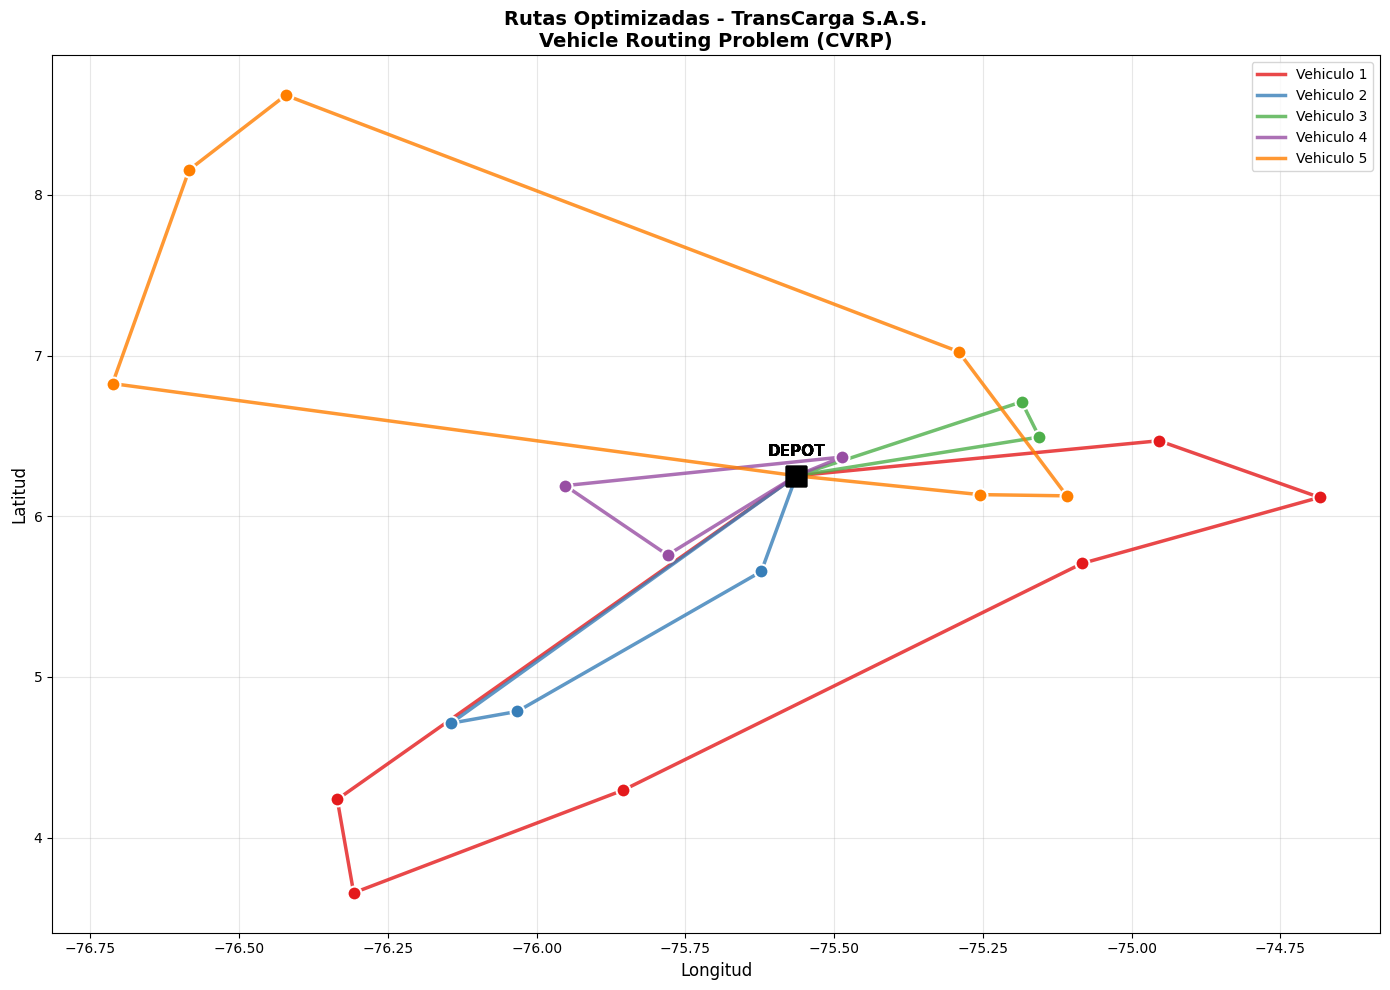

In [7]:
# CELDA 7: Visualizar rutas
print("\n" + "="*70)
print("VISUALIZACION DE RUTAS")
print("="*70)

if df_rutas is not None and len(df_rutas) > 0:
    plt.figure(figsize=(14, 10))
    
    colores = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']
    
    for vehiculo_id in df_rutas['vehiculo_id'].unique():
        ruta_v = df_rutas[df_rutas['vehiculo_id'] == vehiculo_id].sort_values('orden')
        color = colores[(vehiculo_id - 1) % len(colores)]
        
        # Linea de ruta
        plt.plot(ruta_v['longitud'], ruta_v['latitud'], 
                 '-', color=color, linewidth=2.5, alpha=0.8,
                 label=f'Vehiculo {vehiculo_id}')
        
        # Puntos
        for idx, row in ruta_v.iterrows():
            if row['orden'] == 0:
                plt.scatter(row['longitud'], row['latitud'], 
                           c='black', s=200, marker='s', zorder=5)
                plt.annotate('DEPOT', (row['longitud'], row['latitud']),
                            fontsize=11, ha='center', va='bottom',
                            xytext=(0, 12), textcoords='offset points',
                            fontweight='bold')
            elif row['demanda'] > 0:
                plt.scatter(row['longitud'], row['latitud'], 
                           c=color, s=100, marker='o', zorder=4, 
                           edgecolors='white', linewidths=1.5)
                plt.annotate(str(int(row['orden'])), 
                            (row['longitud'], row['latitud']),
                            fontsize=9, ha='center', va='center', 
                            color='white', fontweight='bold')
    
    plt.xlabel('Longitud', fontsize=12)
    plt.ylabel('Latitud', fontsize=12)
    plt.title('Rutas Optimizadas - TransCarga S.A.S.\nVehicle Routing Problem (CVRP)', 
              fontsize=14, fontweight='bold')
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, alpha=0.3)
    
    output_path = os.path.join(RESULTS_DIR, 'rutas_optimizadas.png')
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"\nGrafico guardado: {output_path}")
    
    plt.tight_layout()
    plt.show()
else:
    print("No hay rutas para visualizar")

In [8]:
# CELDA 8: Guardar resultados
print("\n" + "="*70)
print("GUARDANDO RESULTADOS")
print("="*70)

if df_rutas is not None:
    # Guardar rutas
    rutas_path = os.path.join(RESULTS_DIR, 'rutas_optimizadas.csv')
    df_rutas.to_csv(rutas_path, index=False)
    print(f"Rutas guardadas: {rutas_path}")
    
    # Guardar metricas
    if metricas:
        metricas_path = os.path.join(RESULTS_DIR, 'metricas_optimizacion.json')
        with open(metricas_path, 'w') as f:
            json.dump(metricas, f, indent=2)
        print(f"Metricas guardadas: {metricas_path}")
    
    # Reporte por vehiculo
    reporte = []
    for vid in df_rutas['vehiculo_id'].unique():
        ruta_v = df_rutas[df_rutas['vehiculo_id'] == vid]
        reporte.append({
            'vehiculo_id': vid,
            'capacidad_kg': vehicle_capacities[vid-1],
            'clientes_atendidos': len(ruta_v[ruta_v['demanda'] > 0]),
            'carga_total_kg': ruta_v['demanda'].sum(),
            'utilizacion_pct': round(ruta_v['demanda'].sum() / vehicle_capacities[vid-1] * 100, 1)
        })
    
    df_reporte = pd.DataFrame(reporte)
    reporte_path = os.path.join(RESULTS_DIR, 'reporte_vehiculos.csv')
    df_reporte.to_csv(reporte_path, index=False)
    print(f"Reporte vehiculos: {reporte_path}")
    display(df_reporte)
    
    logger.info("Resultados guardados exitosamente")
else:
    print("No hay resultados para guardar")


GUARDANDO RESULTADOS
Rutas guardadas: C:\Users\danie\OneDrive\Documentos\TransCarga_ETL\datos\results\rutas_optimizadas.csv
Metricas guardadas: C:\Users\danie\OneDrive\Documentos\TransCarga_ETL\datos\results\metricas_optimizacion.json
Reporte vehiculos: C:\Users\danie\OneDrive\Documentos\TransCarga_ETL\datos\results\reporte_vehiculos.csv


,vehiculo_id,capacidad_kg,clientes_atendidos,carga_total_kg,utilizacion_pct
0,1,2000,6,2000,100.0
1,2,2000,3,2000,100.0
2,3,2000,2,2000,100.0
3,4,2000,3,2000,100.0
4,5,2000,6,2000,100.0


2026-05-11 13:42:50,005 - INFO - Resultados guardados exitosamente


In [9]:
# CELDA 9: Resumen final
print("\n" + "="*70)
print("RESUMEN DE OPTIMIZACION")
print("="*70)

print("\nMODELO: CVRP (Capacitated Vehicle Routing Problem)")
print("SOLVER: Google OR-Tools")
print(f"TIEMPO DE RESOLUCION: {elapsed:.2f} segundos")

if metricas:
    print(f"\n--- RESULTADOS ---")
    print(f"Distancia optimizada: {metricas['distancia_total_km']:.1f} km")
    print(f"Clientes atendidos: {metricas['clientes_atendidos']}")
    print(f"Carga total: {metricas['carga_total_kg']} kg")
    print(f"Vehiculos utilizados: {metricas['vehiculos_utilizados']}")
    print(f"\n--- COSTO ESTIMADO ---")
    print(f"${metricas['costo_total_cop']:,.0f} COP")
    
    print(f"\n--- ARCHIVOS GENERADOS ---")
    print(f"- {RESULTS_DIR}\\rutas_optimizadas.csv")
    print(f"- {RESULTS_DIR}\\metricas_optimizacion.json")
    print(f"- {RESULTS_DIR}\\reporte_vehiculos.csv")
    print(f"- {RESULTS_DIR}\\rutas_optimizadas.png")

logger.info("Optimizacion completada")

2026-05-11 13:42:50,017 - INFO - Optimizacion completada



RESUMEN DE OPTIMIZACION

MODELO: CVRP (Capacitated Vehicle Routing Problem)
SOLVER: Google OR-Tools
TIEMPO DE RESOLUCION: 60.00 segundos

--- RESULTADOS ---
Distancia optimizada: 530.0 km
Clientes atendidos: 20
Carga total: 10000 kg
Vehiculos utilizados: 5

--- COSTO ESTIMADO ---
$1,239,878 COP

--- ARCHIVOS GENERADOS ---
- C:\Users\danie\OneDrive\Documentos\TransCarga_ETL\datos\results\rutas_optimizadas.csv
- C:\Users\danie\OneDrive\Documentos\TransCarga_ETL\datos\results\metricas_optimizacion.json
- C:\Users\danie\OneDrive\Documentos\TransCarga_ETL\datos\results\reporte_vehiculos.csv
- C:\Users\danie\OneDrive\Documentos\TransCarga_ETL\datos\results\rutas_optimizadas.png


---
## Conclusión

El modelo de optimización de rutas ha sido ejecutado utilizando:

- **Google OR-Tools** como solver
- **CVRP** (Capacitated Vehicle Routing Problem)
- **Estrategia**: PATH_CHEAPEST_ARC + GUIDED_LOCAL_SEARCH

### Resultados:
- Rutas optimizadas para minimizar distancia total
- Respetando restricciones de capacidad por vehículo
- Costos estimados de operación